# Implement Value at Risk & Conditional Value at Risk using:

<b> YouTube Tutorial </b> (Published: Nov 24, 2020): https://youtu.be/04Tv6ZKqABs


    1. Historical Method
    2. Parametric Method (Variance-Covariance)
    3. Monte Carlo Method

## Get the Historical Data
First let's import the dependencies and get the data! We also assign random weightings to the given stock portfoio. Please feel free to change these weightings to whatever allocation you'd like!

In [21]:
## Install required python library 
!python3 -m pip install --upgrade pandas_datareader
!python3 -m pip install pandas numpy
!python3 -m pip install yfinance
!python3 -m pip install scipy matplotlib


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [22]:
import pandas as pd
import numpy as np
import datetime as dt
from pandas_datareader import data as pdr
from scipy.stats import norm, t
import matplotlib.pyplot as plt

In [24]:
import datetime as dt
import numpy as np
import pandas as pd
import yfinance as yf  


def getData(stocks, start, end):
    # Use yf.download instead of pdr.get_data_yahoo
    stockData = yf.download(stocks, start=start, end=end)
    stockData = stockData["Close"]
    returns = stockData.pct_change()
    meanReturns = returns.mean()
    covMatrix = returns.cov()
    return returns, meanReturns, covMatrix


# Portfolio Performance
def portfolioPerformance(weights, meanReturns, covMatrix, Time):
    returns = np.sum(meanReturns*weights)*Time
    std = np.sqrt( np.dot(weights.T, np.dot(covMatrix, weights)) ) * np.sqrt(Time)
    return returns, std

stockList = ['CBA', 'BHP', 'TLS', 'NAB', 'WBC', 'STO']
stocks = [stock+'.AX' for stock in stockList]
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=800)

returns, meanReturns, covMatrix = getData(stocks, start=startDate, end=endDate)
returns = returns.dropna()

weights = np.random.random(len(returns.columns))
weights /= np.sum(weights)

returns['portfolio'] = returns.dot(weights)


[*********************100%***********************]  6 of 6 completed


In [25]:
print("Mean Returns:\n", meanReturns)
print("Covariance Matrix:\n", covMatrix)
print("Portfolio Weights:\n", weights)
print("Portfolio Returns:\n", returns['portfolio'].head())

Mean Returns:
 Ticker
BHP.AX    0.001015
CBA.AX    0.000659
NAB.AX    0.000394
STO.AX    0.000501
TLS.AX    0.000740
WBC.AX    0.000695
dtype: float64
Covariance Matrix:
 Ticker    BHP.AX    CBA.AX    NAB.AX    STO.AX    TLS.AX    WBC.AX
Ticker                                                            
BHP.AX  0.000269  0.000014  0.000031  0.000040 -0.000013  0.000039
CBA.AX  0.000014  0.000207  0.000126  0.000032  0.000021  0.000127
NAB.AX  0.000031  0.000126  0.000187  0.000036  0.000014  0.000137
STO.AX  0.000040  0.000032  0.000036  0.000327  0.000031  0.000037
TLS.AX -0.000013  0.000021  0.000014  0.000031  0.000075  0.000019
WBC.AX  0.000039  0.000127  0.000137  0.000037  0.000019  0.000175
Portfolio Weights:
 [0.03980603 0.04502449 0.28904511 0.20350983 0.21077613 0.21183842]
Portfolio Returns:
 Date
2024-07-01   -0.002650
2024-07-02   -0.002545
2024-07-03   -0.001195
2024-07-04    0.017709
2024-07-05   -0.003854
Name: portfolio, dtype: float64


## Historical VaR

YouTube Tutorial (Published:
Nov 25, 2020): https://youtu.be/90DeUSZ9fEk

Here we make no assumptions about the distribution of returns.

In [26]:

def historicalVaR(returns, alpha=5):
    """
    Read in a pandas dataframe of returns / a pandas series of returns
    Output the percentile of the distribution at the given alpha confidence level
    """
    if isinstance(returns, pd.Series):
        return np.percentile(returns, alpha)

    # A passed user-defined-function will be passed a Series for evaluation.
    elif isinstance(returns, pd.DataFrame):
        return returns.aggregate(historicalVaR, alpha=alpha)

    else:
        raise TypeError("Expected returns to be dataframe or series")

def historicalCVaR(returns, alpha=5):
    """
    Read in a pandas dataframe of returns / a pandas series of returns
    Output the CVaR for dataframe / series
    """
    if isinstance(returns, pd.Series):
        belowVaR = returns <= historicalVaR(returns, alpha=alpha)
        return returns[belowVaR].mean()

    # A passed user-defined-function will be passed a Series for evaluation.
    elif isinstance(returns, pd.DataFrame):
        return returns.aggregate(historicalCVaR, alpha=alpha)

    else:
        raise TypeError("Expected returns to be dataframe or series")

# 100 days
Time = 100

hVaR = -historicalVaR(returns['portfolio'], alpha=5)*np.sqrt(Time)
hCVaR = -historicalCVaR(returns['portfolio'], alpha=5)*np.sqrt(Time)
pRet, pStd = portfolioPerformance(weights, meanReturns, covMatrix, Time)

InitialInvestment = 10000
print('Expected Portfolio Return:      ', round(InitialInvestment*pRet,2))
print('Value at Risk 95th CI    :      ', round(InitialInvestment*hVaR,2))
print('Conditional VaR 95th CI  :      ', round(InitialInvestment*hCVaR,2))

Expected Portfolio Return:       589.26
Value at Risk 95th CI    :       1427.28
Conditional VaR 95th CI  :       2083.28


## Parametric VaR

YouTube Tutorial (Published: Dec 11, 2020): https://youtu.be/bTZP86fHIuI

Here we make an assumption on the distribution of returns abd use the historical portfolio returns and standard deviations (estimates) to define parameters for the model. Here we have implemented two parametric VaR models:
 - normal distribution
 - t-distribution (fatter tails)

In [27]:
def var_parametric(portofolioReturns, portfolioStd, distribution='normal', alpha=5, dof=6):
    # because the distribution is symmetric
    if distribution == 'normal':
        VaR = norm.ppf(1-alpha/100)*portfolioStd - portofolioReturns
    elif distribution == 't-distribution':
        nu = dof
        VaR = np.sqrt((nu-2)/nu) * t.ppf(1-alpha/100, nu) * portfolioStd - portofolioReturns
    else:
        raise TypeError("Expected distribution type 'normal'/'t-distribution'")
    return VaR

def cvar_parametric(portofolioReturns, portfolioStd, distribution='normal', alpha=5, dof=6):
    if distribution == 'normal':
        CVaR = (alpha/100)**-1 * norm.pdf(norm.ppf(alpha/100))*portfolioStd - portofolioReturns
    elif distribution == 't-distribution':
        nu = dof
        xanu = t.ppf(alpha/100, nu)
        CVaR = -1/(alpha/100) * (1-nu)**(-1) * (nu-2+xanu**2) * t.pdf(xanu, nu) * portfolioStd - portofolioReturns
    else:
        raise TypeError("Expected distribution type 'normal'/'t-distribution'")
    return CVaR

pRet, pStd = portfolioPerformance(weights, meanReturns, covMatrix, Time=1)

InitialInvestment = 10000

normVaR = var_parametric(pRet, pStd)
normCVaR = cvar_parametric(pRet, pStd)

tVaR = var_parametric(pRet, pStd, distribution='t-distribution')
tCVaR = cvar_parametric(pRet, pStd, distribution='t-distribution')

print("Normal VaR 95th CI       :      ", round(InitialInvestment*normVaR,2))
print("Normal CVaR 95th CI      :      ", round(InitialInvestment*normCVaR,2))
print("t-dist VaR 95th CI       :      ", round(InitialInvestment*tVaR,2))
print("t-dist CVaR 95th CI      :      ", round(InitialInvestment*tCVaR,2))

Normal VaR 95th CI       :       141.14
Normal CVaR 95th CI      :       178.49
t-dist VaR 95th CI       :       135.93
t-dist CVaR 95th CI      :       186.84


## Monte Carlo VaR & CVaR

YouTube Tutorial (Published: Mar 26, 2021): https://youtu.be/f9MAFvP5-pA

In this section we use a Monte Carlo simulation of a stock portfolio and then use the functions for historical VaR and CVaR to calculate our risk parameters.

The main advantage here is we could define individual models/stock dynamics for individual assets. This can be very powerful!

In [28]:

# Monte Carlo Method
mc_sims = 400 # number of simulations
T = 100 #timeframe in days

meanM = np.full(shape=(T, len(weights)), fill_value=meanReturns)
meanM = meanM.T

portfolio_sims = np.full(shape=(T, mc_sims), fill_value=0.0)

initialPortfolio = 10000

for m in range(0, mc_sims):
    # MC loops
    Z = np.random.normal(size=(T, len(weights)))
    L = np.linalg.cholesky(covMatrix)
    dailyReturns = meanM + np.inner(L, Z)
    portfolio_sims[:,m] = np.cumprod(np.inner(weights, dailyReturns.T)+1)*initialPortfolio

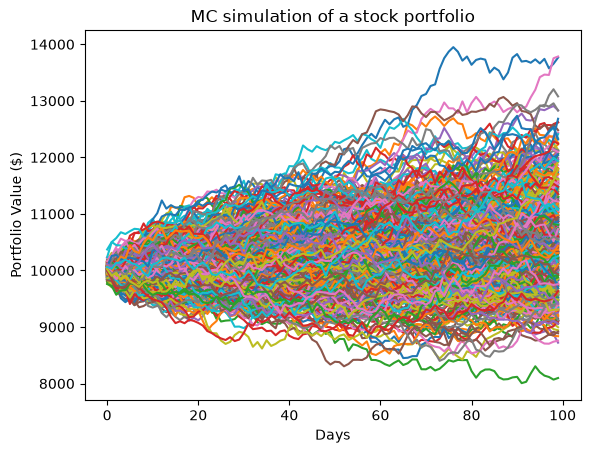

In [29]:

plt.plot(portfolio_sims)
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Days')
plt.title('MC simulation of a stock portfolio')
plt.show()

In [30]:

def mcVaR(returns, alpha=5):
    """ Input: pandas series of returns
        Output: percentile on return distribution to a given confidence level alpha
    """
    if isinstance(returns, pd.Series):
        return np.percentile(returns, alpha)
    else:
        raise TypeError("Expected a pandas data series.")

def mcCVaR(returns, alpha=5):
    """ Input: pandas series of returns
        Output: CVaR or Expected Shortfall to a given confidence level alpha
    """
    if isinstance(returns, pd.Series):
        belowVaR = returns <= mcVaR(returns, alpha=alpha)
        return returns[belowVaR].mean()
    else:
        raise TypeError("Expected a pandas data series.")

In [31]:
portResults = pd.Series(portfolio_sims[-1,:])

VaR = initialPortfolio - mcVaR(portResults, alpha=5)
CVaR = initialPortfolio - mcCVaR(portResults, alpha=5)

print('VaR ${}'.format(round(VaR,2)))
print('CVaR ${}'.format(round(CVaR,2)))

VaR $788.58
CVaR $1024.22


## Comparison of each VaR & CVaR methods

In [32]:
print("\nVaR:")

print(' historical VaR 95th CI   :      ', round(InitialInvestment*hVaR,2))
print(" Normal VaR 95th CI       :      ", round(InitialInvestment*normVaR,2))
print(" t-dist VaR 95th CI       :      ", round(InitialInvestment*tVaR,2))
print(" MC VaR  95th CI          :      ", round(VaR,2))


print("\nCVaR:")

print(' historical CVaR 95th CI  :      ', round(InitialInvestment*hCVaR,2))
print(" Normal CVaR 95th CI      :      ", round(InitialInvestment*normCVaR,2))
print(" t-dist CVaR 95th CI      :      ", round(InitialInvestment*tCVaR,2))
print(" MC CVaR 95th CI          :      ", round(CVaR,2))


VaR:
 historical VaR 95th CI   :       1427.28
 Normal VaR 95th CI       :       141.14
 t-dist VaR 95th CI       :       135.93
 MC VaR  95th CI          :       788.58

CVaR:
 historical CVaR 95th CI  :       2083.28
 Normal CVaR 95th CI      :       178.49
 t-dist CVaR 95th CI      :       186.84
 MC CVaR 95th CI          :       1024.22
